<a href="https://colab.research.google.com/github/mercadocesar995/analisis_ConnectaTel/blob/main/Analisi_ConnectaTel2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [ ]:
print("Primeras 5 filas de PLANS:")
display(plans.head()) # mostrar las primeras 5 filas de plans

Primeras 5 filas de PLANS:


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
print("Primeras 5 filas de USERS:")
display(users.head()) # mostrar las primeras 5 filas de usage

Primeras 5 filas de USERS:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
print("Primeras 5 filas de USAGE:")
display(usage.head())

Primeras 5 filas de USAGE:


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
print("\n--- Información de PLANS ---")
plans.info() # inspección de plans con .info()


--- Información de PLANS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
print("\n--- Información de USERS ---")
users.info() # inspección de users con .info()


--- Información de USERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
print("\n--- Información de USAGE ---")
usage.info() # inspección de usage con .info()


--- Información de USAGE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
print("--- Valores nulos en USERS (Cantidad) ---")
print(users.isna().sum()) # cantidad de nulos para users
print("--- Valores nulos en USAGE (Cantidad) ---")
print(usage.isna().sum()) # Cantidad de valores nulos
print("\n--- Valores nulos en USERS (Proporción %) ---")
print(users.isna().mean() * 100)# Proporción de valores nulos)

--- Valores nulos en USERS (Cantidad) ---
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
--- Valores nulos en USAGE (Cantidad) ---
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

--- Valores nulos en USERS (Proporción %) ---
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
print("--- Valores nulos en USAGE (Cantidad) ---")
print(usage.isna().sum()) # cantidad de nulos para usage

--- Valores nulos en USAGE (Cantidad) ---
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**:
En la revisión del dataset se identificó que la mayoría de los valores nulos responden al funcionamiento natural del negocio, como clientes que aún están activos o campos que no aplican según el tipo de servicio. Se recomienda conservar esos registros, clasificar los datos faltantes de ciudad como “Desconocido”, reemplazar con 0 los valores no aplicables de consumo y eliminar únicamente los 50 registros sin fecha.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint: Fecha de baja (churn_date): Mantener los valores nulos, ya que indican que el cliente continúa activo; se creará una variable para identificar su estado.

* Ciudad (city): Reemplazar los valores nulos por “Desconocido”, conservando los clientes para el análisis.

* Duración (duration): Reemplazar los nulos por 0, porque los mensajes de texto no tienen duración.

* Longitud (length): Reemplazar los nulos por 0, porque las llamadas no registran cantidad de caracteres.

* Fecha de transacción (date): Eliminar los 50 registros sin fecha, debido a que representan menos del 0,1% de la base y no permiten análisis temporal confiable.

  
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

churn_date	~88,4%	Ignorar:	Los nulos representan clientes que siguen activos; no se imputan ni eliminan.

city	~11,7%	Imputar:	Reemplazar los nulos por “Desconocido” para conservar los registros.

duration	Nulos cruzados	Imputar:	Reemplazar por 0 cuando el registro corresponda a mensajes de texto.

length	Nulos cruzados	Imputar:	Reemplazar por 0 cuando el registro corresponda a llamadas.

date	<0,1% (50 registros)	Eliminar: Eliminar las filas sin fecha porque no permiten ubicarlas temporalmente y representan una proporción mínima.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: Es un número único que identifica a cada cliente. Va de 10.000 a 13.999 y no debe utilizarse para calcular promedios u otras métricas, porque no representa una característica del cliente.
- La columna `age`: Se identifica un valor atípico de -999, incompatible con una edad real y probablemente asociado a un error de captura o valor marcador. Este registro distorsiona el promedio, por lo que debe tratarse antes del análisis. Al excluirlo, la distribución muestra una mediana de 47 años y el 50% central de los usuarios se concentra entre 32 y 63 años, con un máximo de 79 años.

In [ ]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- Valores únicos y frecuencias para {col} ---")
    print(users[col].value_counts(dropna=False))
    print("\n")


--- Valores únicos y frecuencias para city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


--- Valores únicos y frecuencias para plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna `city` Presenta las ciudades de los usuarios, con 469 valores nulos y 96 registros con ?; estos valores debera reemplazarse como Desconocido.
- La columna `plan` Presenta dos categorías válidas: Básico (64,9%) y Premium (35,1%), sin valores faltantes ni inconsistencias.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type`: Es una variable categórica que clasifica cada registro de consumo en call (llamada) o message (mensaje). Presenta únicamente estas dos categorías, sin valores nulos ni registros inconsistentes.


---
✍️ **Comentario**:
**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

El único valor claramente inválido identificado hasta ahora es age = -999. Lo trataría como un dato erróneo y lo convertiría en NaN, sin eliminar al usuario.

En cambio, call y message en type son valores válidos, por lo que no requieren ninguna modificación. Para duration y length todavía corresponde realizar una validación de valores mínimos y máximos antes de determinar si existen datos inválidos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [ ]:
users['reg_date'].dt.year.value_counts().sort_index() # Revisar los años presentes en `reg_date` de users


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, Las fechas de registro se concentran entre 2022 y 2024, período esperado para el dataset.

In [ ]:
print("Cantidad de registros por año en date:")
print(usage['date'].dt.year.value_counts().sort_index())# Revisar los años presentes en `date` de usage


Cantidad de registros por año en date:
2024.0    39950
Name: date, dtype: int64


En `date`, La mayoría de los registros de consumo se concentran en 2024 (39.950 registros), lo que indica que este es el principal período de actividad registrado en el dataset. Es importante validar si los registros restantes corresponden a otros años esperados o si existen fechas fuera del período establecido.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Se identificaron 40 registros correspondientes al año 2026, los cuales están fuera del rango de datos establecido y probablemente representan un error de captura. Se recomienda revisar estos registros y, si se confirma que las fechas son incorrectas, corregirlas utilizando la fuente original o convertirlas en valores nulos (NaT) para evitar que afecten el análisis temporal.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
users['city'] = users['city'].replace('?', pd.NA) # Reemplazar ? por NA en city


users['city'].value_counts(dropna=False) # Verificar cambios


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT # Marcar fechas futuras como NA para reg_date


print("Fechas nulas:", users['reg_date'].isna().sum()) # Verificar cambios


Fechas nulas: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()) # Verificación MAR en usage (Missing At Random) para duration


type
call        0
text    22076
Name: duration, dtype: int64

In [ ]:
usage.groupby('type')['length'].apply(lambda x: x.isna().sum()) # Verificación MAR en usage (Missing At Random) para length


type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`:

Los nulos en duration y length dependen directamente del tipo de servicio. En duration, se identifican 22.076 nulos en mensajes de texto (text), mientras que en length hay 17.896 nulos en llamadas (call). Esto indica que son datos que no aplican según el tipo de consumo, por lo que se consideran nulos estructurales (MAR) y se recomienda mantenerlos como nulos, sin imputarlos

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage['is_message'] = (usage['type'] == 'text').astype(int) #conocer el total de mensajes
usage['is_call'] = (usage['type'] == 'call').astype(int) #conocer el total de llamadas
usage['call_minutes'] = usage['duration'].fillna(0)
# Agrupar información por usuario
# observar resultado

In [ ]:
usage_summary = usage.groupby('user_id').agg(
    total_messages=('is_message', 'sum'),
    total_calls=('is_call', 'sum'),
    total_call_minutes=('call_minutes', 'sum')
).reset_index() # Renombrar columnas

usage_summary.head() # observar resultado


,user_id,total_messages,total_calls,total_call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_summary,
    on='user_id',
    how='left'
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_messages,total_calls,total_call_minutes
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
user_profile[['age', 'total_messages', 'total_calls', 'total_call_minutes']].describe()

,age,total_messages,total_calls,total_call_minutes
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
user_profile['plan'].value_counts(normalize=True) * 100 # Distribución porcentual del tipo de plan


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

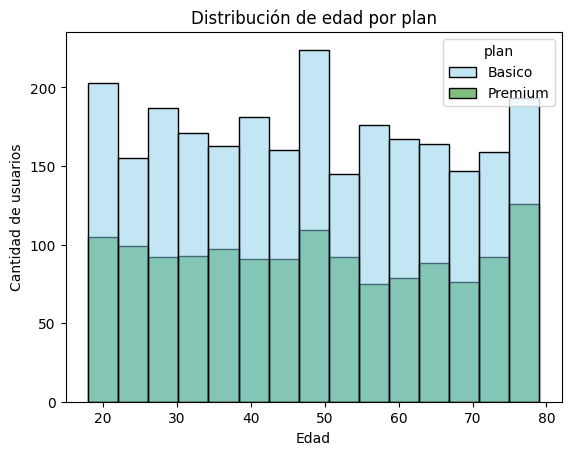

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- La distribución de edades es similar entre los planes Básico y Premium, sin una diferencia clara que indique que la edad determine la elección del plan. La distribución es aproximadamente uniforme.

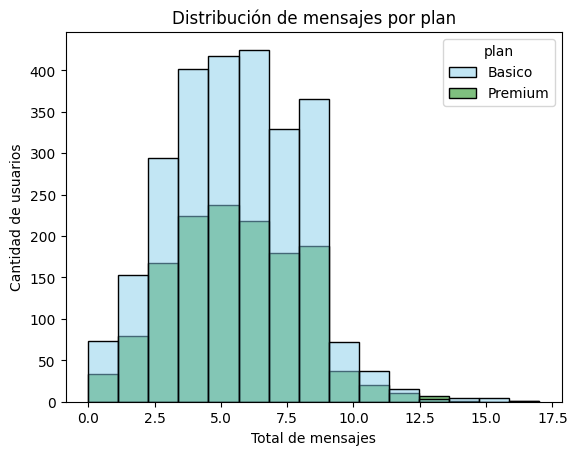

In [ ]:
sns.histplot(
    data=user_profile,
    x='total_messages',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
) # Histograma para visualizar la cant_mensajes

plt.title('Distribución de mensajes por plan')
plt.xlabel('Total de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- Los usuarios de ambos planes presentan un comportamiento de mensajería muy similar, concentrándose principalmente entre 2 y 9 mensajes. La distribución presenta sesgo hacia la derecha, debido a algunos usuarios con consumos más altos.

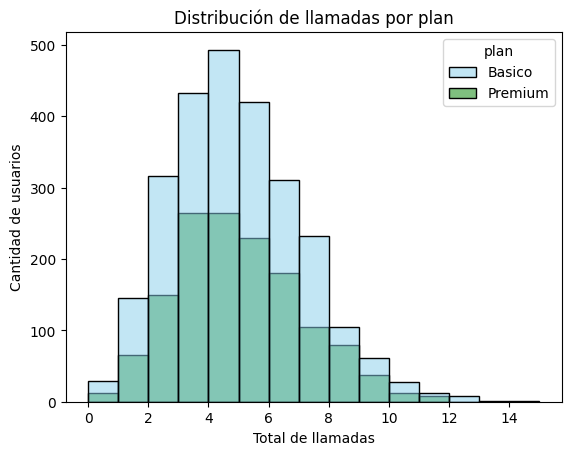

In [ ]:
sns.histplot(
    data=user_profile,
    x='total_calls',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
) # Histograma para visualizar la cant_llamadas

plt.title('Distribución de llamadas por plan')
plt.xlabel('Total de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights:
- Los usuarios de ambos planes presentan una distribución muy similar en la cantidad de llamadas, concentrándose principalmente entre 3 y 7 llamadas por usuario, con un máximo alrededor de 4–5 llamadas. La distribución presenta un ligero sesgo hacia la derecha, debido a que existen pocos usuarios con más de 8 llamadas.

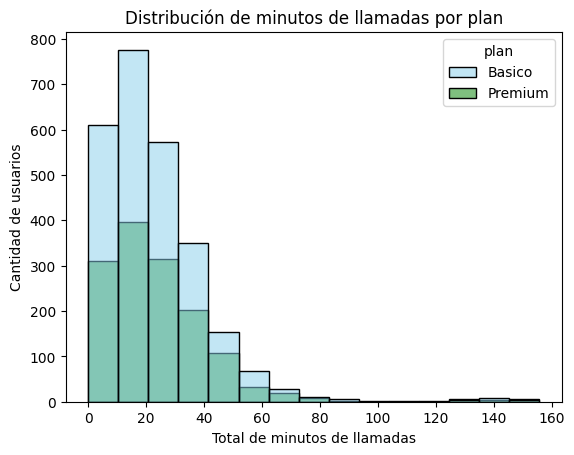

In [ ]:
sns.histplot(
    data=user_profile,
    x='total_call_minutes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
) # Histograma para visualizar la cant_minutos_llamada

plt.title('Distribución de minutos de llamadas por plan')
plt.xlabel('Total de minutos de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights:
- El consumo de minutos se concentra principalmente entre 0 y 40 minutos, tanto para usuarios Básico como Premium. La distribución presenta un claro sesgo hacia la derecha, debido a un número reducido de usuarios con consumos superiores a 60 minutos y algunos valores extremos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

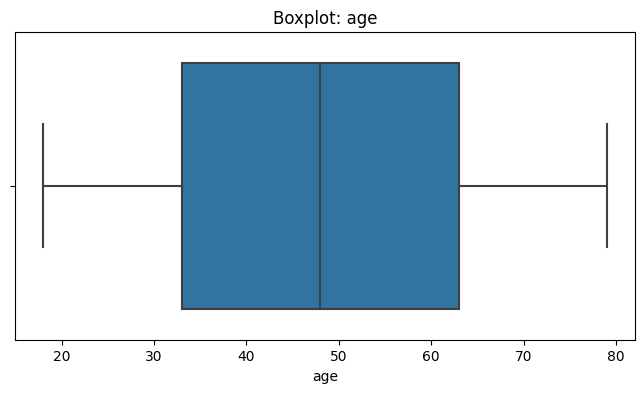

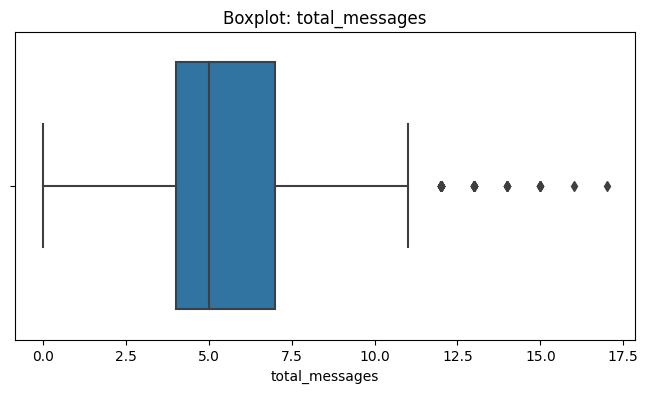

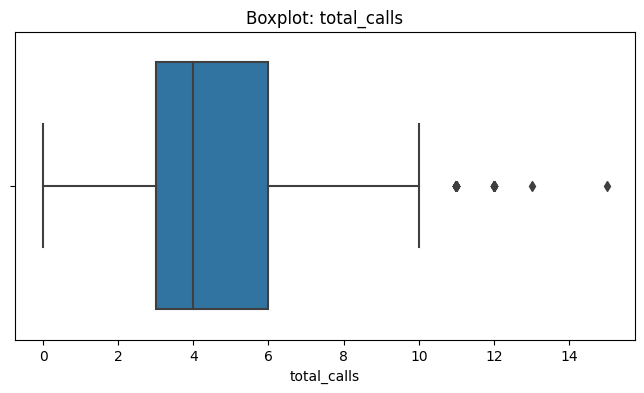

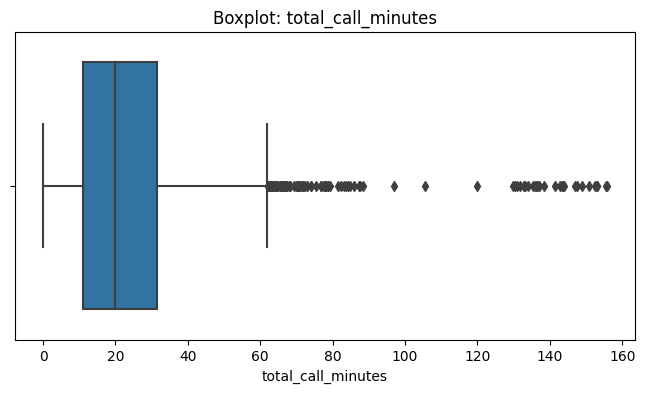

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'total_messages', 'total_calls', 'total_call_minutes']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- **Age**: No se observan outliers evidentes. Los valores de edad se encuentran dentro de un rango razonable y no presentan puntos fuera de los límites del boxplot. Por lo tanto, no se requiere una limpieza adicional por valores extremos en esta variable.
- **Cant_mensajes**: Se observan varios outliers en la parte superior de la distribución, correspondientes a clientes con un número de mensajes considerablemente mayor que el comportamiento habitual. Estos valores no necesariamente representan errores, por lo que se recomienda conservarlos inicialmente y analizarlos como posibles clientes de alto consumo.
- **Cant_llamadas**: Se identifican algunos usuarios con una cantidad de llamadas considerablemente superior a la mayoría. Estos valores pueden corresponder a clientes con un alto uso del servicio y deben conservarse para analizar su comportamiento.
- **Cant_minutos_llamada**: Se identifican algunos usuarios con un consumo de minutos considerablemente superior al de la mayoría. Estos valores pueden representar un alto uso y real del servicio, por lo que no se recomienda eliminarlos.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'total_messages', 'total_calls', 'total_call_minutes']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f'\n--- {col} ---')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite inferior: {limite_inferior}')
    print(f'Límite superior: {limite_superior}')




--- age ---
Q1: 33.0
Q3: 63.0
IQR: 30.0
Límite inferior: -12.0
Límite superior: 108.0

--- total_messages ---
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5

--- total_calls ---
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5

--- total_call_minutes ---
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575


In [ ]:
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    maximo = user_profile[col].max()
    minimo = user_profile[col].min()

    print(f'\n--- {col} ---')
    print(f'Mínimo: {minimo}')
    print(f'Límite inferior: {limite_inferior:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Máximo: {maximo}') # Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


--- age ---
Mínimo: 18.0
Límite inferior: -12.00
Límite superior: 108.00
Máximo: 79.0

--- total_messages ---
Mínimo: 0.0
Límite inferior: -0.50
Límite superior: 11.50
Máximo: 17.0

--- total_calls ---
Mínimo: 0.0
Límite inferior: -1.50
Límite superior: 10.50
Máximo: 15.0

--- total_call_minutes ---
Mínimo: 0.0
Límite inferior: -19.32
Límite superior: 61.86
Máximo: 155.69


,age,total_messages,total_calls,total_call_minutes
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- **Cant_mensajes: mantener o no outliers, porqué?**: Mantener los outliers: El límite superior es de 11,5 mensajes y el máximo observado es de 17. Aunque es un valor atípico, sigue siendo posible para un usuario real. Se recomienda mantenerlo para no perder información sobre clientes de mayor consumo, relevante para estrategias y ofertas comerciales.
  
- **Cant_llamadas: mantener o no outliers, porqué?**: Se recomienda mantener los valores atípicos en la cantidad de llamadas. Al no tratarse de errores de medición o corrupción de datos, sino de un comportamiento real de consumo elevado, conservarlos en el conjunto de datos aporta valor estratégico.

  
- **Cant_minutos_llamada: mantener o no outliers, porqué?**: Se identifican usuarios con mayor consumo de minutos superior al comportamiento habitual. Estos valores pueden representar un uso intensivo y real del servicio, se recomienda mantenerlos y analizarlos como posibles clientes de alto consumo.

---
## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:

def clasificar_uso(row):
    if row['total_calls'] < 5 and row['total_messages'] < 5:
        return 'Bajo uso'
    elif row['total_calls'] < 10 and row['total_messages'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1) # Crear columna grupo_uso


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_messages,total_calls,total_call_minutes,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad
🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)# Crear columna grupo_edad


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_messages,total_calls,total_call_minutes,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

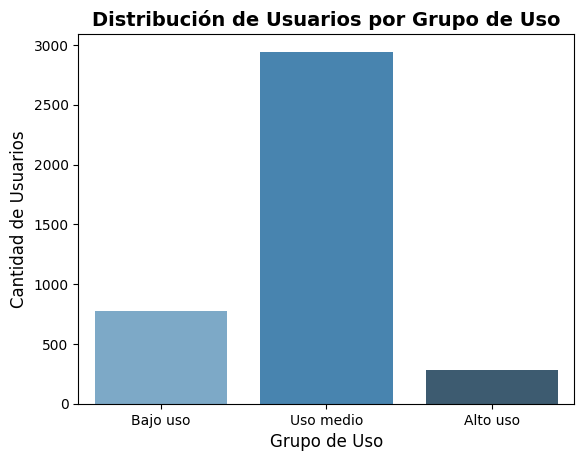

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette='Blues_d',
    order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Grupo de Uso', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Uso', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

plt.show()

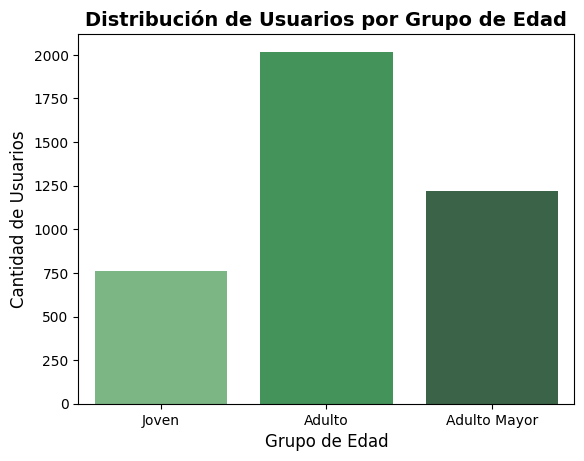

In [ ]:
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette='Greens_d',
    order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.show() # Visualización de los segmentos por edad



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


Los principales problemas encontrados fueron valores faltantes, sentinels y fechas fuera de rango. En age se identificó el sentinel -999, que representaba un registro (0,025% de los 4.000 usuarios), y posteriormente se reemplazó por la mediana. En city se encontraron 469 valores nulos (11,7%) y 96 registros con ? (2,4%), que fueron tratados como valores nulos. Además, reg_date presentó 40 registros con fechas de 2026 (1%), fuera del período válido hasta 2024, que fueron marcados como nulos. Los valores faltantes de duration y length se conservaron porque dependen del tipo de servicio y representan datos que no aplican.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

El análisis identifica tres segmentos según la intensidad de uso: Bajo uso (800 usuarios), Uso medio (3.000 usuarios) y Alto uso (300 usuarios). La mayor concentración se encuentra en el segmento de uso medio, lo que indica que la mayoría de los clientes mantiene un consumo moderado del servicio. En términos demográficos, los Adultos representan el grupo más numeroso (2.000 usuarios), mientras que Jóvenes y Adultos Mayores presentan una participación similar (1.200 usuarios cada uno). No se observa una relación clara entre la edad y el nivel de consumo, por lo que la segmentación comercial debería priorizar la intensidad y los patrones de uso sobre la edad. El segmento de alto consumo representa una oportunidad para estrategias de upselling, fidelización y ofertas personalizadas, mientras que el segmento de uso medio podría ser el principal objetivo para incrementar progresivamente el nivel de consumo.


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

El segmento de Alto uso (300 usuarios) parece ser el más valioso, ya que concentra clientes con un consumo significativamente superior al comportamiento promedio en llamadas, mensajes y minutos. Este grupo representa una oportunidad para generar mayores ingresos mediante estrategias de upselling, planes Premium o paquetes adicionales, además de acciones de fidelización para evitar su pérdida. El segmento de Uso medio (3.000 usuarios) también es estratégico por su tamaño y representa una oportunidad de crecimiento, ya que pequeñas mejoras en su nivel de consumo podrían generar un impacto comercial significativo.


- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Se identificaron outliers principalmente en total_messages, total_calls y total_call_minutes. Aunque superan los límites estadísticos del IQR, no representan valores imposibles y pueden corresponder a clientes de alto consumo, estos usuarios son relevantes porque permiten identificar segmentos con necesidades de consumo superiores al promedio, que podrían ser objetivo de planes, paquetes adicionales u ofertas comerciales diferenciadas, se recomienda conservar estos outliers y analizarlos como un posible segmento de alto valor.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

ConnectaTel podría crear planes segmentados según el nivel y tipo de consumo, especialmente para clientes de alto uso de llamadas, minutos o mensajes. También sería recomendable ofrecer paquetes adicionales y opciones flexibles que permitan ajustar los servicios a las necesidades de cada usuario, aprovechando los patrones de consumo para generar ofertas más personalizadas y mejorar la satisfacción y fidelización de los clientes.

✍️ **Escribe aquí tu análisis ejecutivo:**

El análisis de clientes y registros de uso muestra que hay una base concentrada principalmente en niveles de consumo bajos y medios, con promedios de 5,52 mensajes, 4,48 llamadas. Los mensajes representan el 55,23% del uso, frente al 44,77% de las llamadas. Aunque la mayoría presenta un comportamiento moderado, existe un grupo reducido de clientes con consumos elevados que puede representar una oportunidad para segmentar clientes, personalizar ofertas y evaluar migraciones hacia planes de mayor valor.

En cuanto a la calidad de los datos, se identificaron valores nulos e inconsistencias especialmente fechas de registro posteriores al período estudiado y valores de edad inválidos. Los nulos en churn_date, por su parte, pueden ser de clientes que no han cancelado el servicio. Se pueden identificar patrones claros de consumo y oportunidades de segmentación, pero se recomienda realizar una depuración puntual para asegurar que las decisiones comerciales se basen en información confiable.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

-Se revisaron las tablas PLANS, USERS y USAGE. PLANS no presentó valores faltantes. En USERS se identificaron 469 valores nulos en city y 3.534 en churn_date, mientras que en USAGE se encontraron 50 valores nulos en date. Los valores faltantes de duration y length fueron analizados teniendo en cuenta la variable type, ya que corresponden a diferentes tipos de interacción (llamadas y mensajes) y, por tanto, no se trataron automáticamente como errores.

Como parte de la transformación, las variables reg_date, churn_date y date se convirtieron al formato fecha para facilitar el análisis temporal y la generación de métricas. Adicionalmente, se revisaron los valores extremos de total_messages_x, total_calls_x y total_call_minutes_x y se conservaron sin modificaciones, al determinarse que representaban comportamientos reales de clientes con consumo intensivo. De esta manera, la limpieza buscó mejorar la consistencia de la información sin eliminar comportamientos relevantes para la segmentación de clientes


🔍 **Segmentos por Edad**

- Durante la revisión de calidad de datos se identificó un valor atípico de -999 en la variable age, el cual no corresponde a una edad válida. Para evitar que este registro afectara la segmentación, fue reemplazado por la mediana de las edades válidas, conservando así el registro sin introducir un valor extremo en el análisis.

Después de la corrección, el segmento de Adultos (30–59 años) representa el grupo más grande de ConnectaTel, con aproximadamente 2.000 clientes (50%), mientras que Jóvenes (<30 años) y Adultos Mayores (60+ años) presentan una participación similar, cercana a 1.200 usuarios cada uno (25%). La distribución de los planes Básico y Premium se mantiene relativamente equilibrada entre los grupos de edad, lo que sugiere que la edad no es el principal factor para explicar la elección del plan o el nivel de consumo


📊 **Segmentos por Nivel de Uso**

- Para construir la segmentación se analizaron las variables de mensajes y llamadas realizadas por cada cliente, clasificándolos según su intensidad de uso en niveles Bajo, Medio y Alto. Los valores extremos identificados durante la revisión fueron conservados, ya que correspondían a comportamientos reales de clientes y permitían identificar adecuadamente a los usuarios de consumo intensivo.

La mayor parte de la base se concentra en Uso medio (~3.000 clientes), seguido por Bajo uso (~800) y un grupo reducido de Alto uso (~300). Esto indica que el nivel de uso permite diferenciar mejor las oportunidades comerciales que la edad: los clientes de Alto uso representan una oportunidad de upselling, especialmente aquellos que permanecen en el plan Básico, mientras que el segmento de Uso medio puede ser incentivado mediante paquetes adicionales de minutos o mensajes para aumentar progresivamente su consumo.


➡️ Esto sugiere que que el comportamiento de uso es un mejor criterio para entender y accionar sobre los clientes que la edad. La base está concentrada en usuarios de consumo medio, pero existe un grupo pequeño de clientes de alto uso que puede tener mayor potencial de monetización, especialmente si algunos todavía están en el plan Básico.
Tambien sugiere 3 lineas de accion comercial Alto uso: priorizar estrategias de upselling hacia Premium, especialmente en clientes Básicos con consumo elevado.
Uso medio: desarrollar micro-paquetes de minutos y mensajes para aumentar gradualmente el valor generado.
Bajo uso: analizar señales de desinterés o riesgo de churn y diseñar acciones de activación o retención.

En cuanto a la edad, los resultados sugieren que no debería utilizarse como principal criterio para definir la oferta comercial, ya que los patrones de consumo y la distribución de planes no muestran una relación fuerte con los grupos etarios. Por tanto, ConnectaTel debería avanzar hacia una segmentación basada en comportamiento, utilizando el nivel de uso como una de las principales variables para orientar las decisiones comerciales.

💡 **Recomendaciones**

-Cruzar el segmento de Alto uso con el plan contratado para identificar cuántos clientes de alto consumo permanecen en Básico y evaluar si existe una oportunidad real de upselling hacia Premium.

-Dividir los aproximadamente 3.000 clientes de Uso medio según su intensidad de consumo para identificar grupos con diferentes necesidades antes de definir ofertas o paquetes adicionales.

-Cruzar grupo_uso, plan y churn_date para determinar si los clientes de Alto o Bajo uso presentan diferencias en cancelación. Esto permitirá orientar acciones de retención únicamente hacia los segmentos donde exista evidencia de mayor riesgo.

-Analizar el comportamiento de los aproximadamente 800 clientes de Bajo uso y su relación con el churn para determinar si requieren acciones de activación, retención o simplemente representan clientes con una necesidad de consumo naturalmente baja.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---
Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`: https://github.com/mercadocesar995/analisis_ConnectaTel.git


<div class="alert alert-block alert-warning">
<b>Comentario del Revisor [1° iteración]</b> <a class="tocSkip"></a><br>
<b>Atención</b>

Excelente iniciativa al incluir el enlace a tu repositorio de GitHub! Asegúrate de que el repositorio sea público y que, además del archivo README.md, subas la versión final de este notebook (.ipynb) para que tu portafolio esté completo.
</div>